In [1]:
pip install numpy==1.26.4 pandas scikit-learn matplotlib numba aeon


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
# IMPORTS
import os
os.environ["KMP_WARNINGS"] = "0"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import sys
import json
import time
import shutil
import warnings
import subprocess
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import RidgeClassifierCV, LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

from aeon.datasets import load_classification

warnings.filterwarnings("ignore")


In [4]:

# GET THE OFFICIAL MINIROCKET CODE
REPO_DIR = Path("minirocket_official_repo")

if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/angus924/minirocket.git", str(REPO_DIR)],
        check=True
    )

CODE_DIR = REPO_DIR / "code"
if str(CODE_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(CODE_DIR.resolve()))

from minirocket import fit, transform


In [7]:
# PAPER RESULTS FROM THE OFFICIAL REPOSITORY
paper_results_csv = r'''dataset,accuracy,time_training_seconds,time_test_seconds
ACSF1,0.822333,0.49,0.25
Adiac,0.801705,0.45,0.23
ArrowHead,0.880952,0.13,0.14
BME,0.992222,0.11,0.07
Beef,0.761111,0.17,0.04
BeetleFly,0.906667,0.14,0.02
BirdChicken,0.908333,0.15,0.02
CBF,0.996222,0.08,0.4
Car,0.921111,0.2,0.07
Chinatown,0.968999,0.1,0.12
ChlorineConcentration,0.753351,0.56,2.15
CinCECGTorso,0.875797,0.41,3.82
Coffee,0.99881,0.15,0.03
Computers,0.793867,0.52,0.32
CricketX,0.825128,0.53,0.3
CricketY,0.841368,0.53,0.3
CricketZ,0.842479,0.53,0.3
Crop,0.752248,102.87,6.38
DiatomSizeReduction,0.94281,0.1,0.26
DistalPhalanxOutlineAgeGroup,0.803837,0.38,0.06
DistalPhalanxOutlineCorrect,0.821377,0.6,0.12
DistalPhalanxTW,0.695923,0.38,0.06
ECG200,0.899333,0.17,0.04
ECG5000,0.946133,0.59,2.34
ECGFiveDays,0.990476,0.08,0.42
EOGHorizontalSignal,0.83628,1.08,0.75
EOGVerticalSignal,0.798066,1.08,0.75
Earthquakes,0.748681,0.52,0.13
ElectricDevices,0.874366,179.88,2.97
EthanolLevel,0.664,2.01,1.53
FaceAll,0.983452,0.59,0.82
FaceFour,0.940152,0.15,0.09
FacesUCR,0.96865,0.22,1.0
FiftyWords,0.829011,0.63,0.35
Fish,0.975048,0.33,0.18
FordA,0.948182,18.99,1.38
FordB,0.92679,19.23,0.84
FreezerRegularTrain,0.999123,0.27,2.21
FreezerSmallTrain,0.987322,0.12,2.26
GunPoint,0.992444,0.14,0.09
GunPointAgeSpan,0.9923,0.22,0.19
GunPointMaleVersusFemale,0.999895,0.18,0.19
GunPointOldVersusYoung,1.0,0.2,0.19
Ham,0.844762,0.25,0.1
Haptics,0.546212,0.48,0.55
Herring,0.609375,0.19,0.06
HouseTwenty,0.965826,0.42,0.41
InlineSkate,0.464667,0.62,1.79
InsectEPGRegularTrain,1.0,0.21,0.31
InsectEPGSmallTrain,0.99344,0.14,0.31
InsectWingbeatSound,0.65968,0.28,1.2
ItalyPowerDemand,0.959572,0.09,0.35
LargeKitchenAppliances,0.9032,0.74,0.47
Lightning2,0.751913,0.24,0.09
Lightning7,0.778995,0.19,0.07
Mallat,0.955892,0.31,3.74
Meat,0.993333,0.18,0.05
MedicalImages,0.804386,0.37,0.34
MiddlePhalanxOutlineAgeGroup,0.708009,0.37,0.06
MiddlePhalanxOutlineCorrect,0.842726,0.6,0.13
MiddlePhalanxTW,0.590909,0.38,0.07
MixedShapesRegularTrain,0.969361,1.25,3.9
MixedShapesSmallTrain,0.941388,0.39,3.9
MoteStrain,0.912913,0.06,0.59
OSULeaf,0.957576,0.34,0.23
OliveOil,0.914444,0.17,0.04
PhalangesOutlinesCorrect,0.84223,3.29,0.35
Phoneme,0.271871,0.62,3.11
PigAirwayPressure,0.872756,0.66,0.72
PigArtPressure,0.9625,0.65,0.73
PigCVP,0.91859,0.67,0.74
Plane,1.0,0.18,0.06
PowerCons,0.983704,0.24,0.09
ProximalPhalanxOutlineAgeGroup,0.856585,0.37,0.09
ProximalPhalanxOutlineCorrect,0.894158,0.59,0.13
ProximalPhalanxTW,0.802114,0.38,0.09
RefrigerationDevices,0.696978,0.75,0.47
Rock,0.815333,0.45,0.27
ScreenType,0.542222,0.75,0.47
SemgHandGenderCh2,0.909889,1.14,1.54
SemgHandMovementCh2,0.675037,1.6,1.17
SemgHandSubjectCh2,0.878667,1.6,1.16
ShapeletSim,0.99963,0.14,0.2
ShapesAll,0.934778,1.0,0.58
SmallKitchenAppliances,0.813333,0.74,0.47
SmoothSubspace,0.958,0.21,0.04
SonyAIBORobotSurface1,0.948031,0.09,0.25
SonyAIBORobotSurface2,0.941728,0.07,0.34
StarLightCurves,0.981221,2.57,13.21
Strawberry,0.97982,0.78,0.25
SwedishLeaf,0.962933,0.51,0.28
Symbols,0.966834,0.11,0.91
SyntheticControl,0.990111,0.3,0.14
ToeSegmentation1,0.941082,0.14,0.18
ToeSegmentation2,0.94,0.16,0.12
Trace,1.0,0.2,0.07
TwoLeadECG,0.997249,0.08,0.51
TwoPatterns,0.995283,1.26,1.76
UMD,0.990278,0.14,0.09
UWaveGestureLibraryAll,0.974912,2.39,6.05
UWaveGestureLibraryX,0.856049,1.47,3.01
UWaveGestureLibraryY,0.783398,1.5,3.05
UWaveGestureLibraryZ,0.800326,1.54,3.03
Wafer,0.998978,1.4,3.5
Wine,0.927778,0.15,0.04
WordSynonyms,0.767555,0.37,0.48
Worms,0.729437,0.49,0.13
WormsTwoClass,0.792641,0.48,0.12
Yoga,0.918689,0.53,2.73
'''

paper_results = pd.read_csv(StringIO(paper_results_csv))
paper_results.head()


,dataset,accuracy,time_training_seconds,time_test_seconds
0,ACSF1,0.822333,0.49,0.25
1,Adiac,0.801705,0.45,0.23
2,ArrowHead,0.880952,0.13,0.14
3,BME,0.992222,0.11,0.07
4,Beef,0.761111,0.17,0.04


In [9]:
# SETTINGS
BASE_DIR = Path("minirocket_project_outputs")
BASE_DIR.mkdir(parents=True, exist_ok=True)

REPRO_DIR = BASE_DIR / "reproduction"
REPRO_DIR.mkdir(parents=True, exist_ok=True)

IMPROVE_DIR = BASE_DIR / "improvements"
IMPROVE_DIR.mkdir(parents=True, exist_ok=True)

PAPER_DATASETS = paper_results["dataset"].tolist()

# use None for the full 109
# use a small number like 5 or 10 first if you want to test
USE_FIRST_N = None

if USE_FIRST_N is None:
    REPRO_DATASETS = PAPER_DATASETS
else:
    REPRO_DATASETS = PAPER_DATASETS[:USE_FIRST_N]

# keep improvement study smaller
IMPROVEMENT_DATASETS = [
    "Beef",
    "Coffee",
    "ECG200",
    "FaceFour",
    "GunPoint",
    "ItalyPowerDemand",
    "OliveOil",
    "SonyAIBORobotSurface1",
    "TwoLeadECG",
    "Wafer"
]

BASELINE_NUM_FEATURES = 10_000
IMPROVED_NUM_FEATURES = 20_000
RIDGE_ALPHAS = np.logspace(-3, 3, 10)


In [31]:
# HELPERS
def save_text(path, text):
    path.write_text(text, encoding="utf-8")


def load_ucr_univariate(dataset_name):
    X_train, y_train = load_classification(dataset_name, split="train")
    X_test, y_test = load_classification(dataset_name, split="test")

    if X_train.shape[1] != 1 or X_test.shape[1] != 1:
        raise ValueError(f"{dataset_name} is not univariate in the expected format")

    X_train = X_train[:, 0, :].astype(np.float32)
    X_test = X_test[:, 0, :].astype(np.float32)

    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)

    return X_train, y_train, X_test, y_test, le


def make_ridge_classifier():
    # official README examples use RidgeClassifierCV(..., normalize=True)
    # current sklearn removed normalize, so StandardScaler + RidgeClassifierCV is the closest modern replacement
    return make_pipeline(
        StandardScaler(),
        RidgeClassifierCV(alphas=RIDGE_ALPHAS)
    )


def make_logreg_classifier():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=42)
    )


def make_linearsvc_classifier():
    return make_pipeline(
        StandardScaler(),
        LinearSVC(max_iter=10000, random_state=42)
    )


def run_minirocket_pipeline(X_train, y_train, X_test, y_test, classifier, num_features=10_000):
    start_train = time.time()
    parameters = fit(X_train, num_features=num_features)
    X_train_t = transform(X_train, parameters)
    classifier.fit(X_train_t, y_train)
    train_time = time.time() - start_train

    start_test = time.time()
    X_test_t = transform(X_test, parameters)
    y_pred = classifier.predict(X_test_t)
    test_time = time.time() - start_test

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "train_time_seconds": train_time,
        "test_time_seconds": test_time,
        "y_pred": y_pred
    }


In [33]:
# REPRODUCTION: OFFICIAL MINIROCKET METHOD
def run_reproduction_benchmark(datasets, reset=False):
    results_path = REPRO_DIR / "reproduction_results.csv"
    failed_path = REPRO_DIR / "reproduction_failed.csv"

    if reset or not results_path.exists():
        results_df = pd.DataFrame()
    else:
        results_df = pd.read_csv(results_path)

    if reset or not failed_path.exists():
        failed_df = pd.DataFrame(columns=["dataset", "error"])
    else:
        failed_df = pd.read_csv(failed_path)

    done = set(results_df["dataset"].tolist()) if len(results_df) else set()
    failed = set(failed_df["dataset"].tolist()) if len(failed_df) else set()

    for i, dataset_name in enumerate(datasets, start=1):
        if dataset_name in done or dataset_name in failed:
            continue

        try:
            X_train, y_train, X_test, y_test, le = load_ucr_univariate(dataset_name)

            result = run_minirocket_pipeline(
                X_train=X_train,
                y_train=y_train,
                X_test=X_test,
                y_test=y_test,
                classifier=make_ridge_classifier(),
                num_features=BASELINE_NUM_FEATURES
            )

            row = {
                "dataset": dataset_name,
                "our_accuracy": result["accuracy"],
                "our_balanced_accuracy": result["balanced_accuracy"],
                "our_macro_f1": result["macro_f1"],
                "our_train_time_seconds": result["train_time_seconds"],
                "our_test_time_seconds": result["test_time_seconds"],
                "train_size": len(X_train),
                "test_size": len(X_test),
                "series_length": X_train.shape[1],
                "num_classes": len(le.classes_)
            }

            results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)
            results_df.to_csv(results_path, index=False)

            report = classification_report(y_test, result["y_pred"], target_names=le.classes_, digits=4)
            save_text(REPRO_DIR / f"{dataset_name}_classification_report.txt", report)

            print(f"{i}/{len(datasets)} {dataset_name} {row['our_accuracy']:.4f}")

        except Exception as e:
            failed_df = pd.concat([
                failed_df,
                pd.DataFrame([{"dataset": dataset_name, "error": str(e)}])
            ], ignore_index=True)
            failed_df.to_csv(failed_path, index=False)
            print(f"{i}/{len(datasets)} {dataset_name} failed")

    return results_df, failed_df


In [35]:
repro_results, repro_failed = run_reproduction_benchmark(REPRO_DATASETS, reset=False)


In [17]:
# PAPER VS OUR RESULTS
paper_vs_ours = paper_results.merge(repro_results, on="dataset", how="left")
paper_vs_ours["accuracy_diff"] = paper_vs_ours["our_accuracy"] - paper_vs_ours["accuracy"]
paper_vs_ours["train_time_diff"] = paper_vs_ours["our_train_time_seconds"] - paper_vs_ours["time_training_seconds"]
paper_vs_ours["test_time_diff"] = paper_vs_ours["our_test_time_seconds"] - paper_vs_ours["time_test_seconds"]

paper_vs_ours.to_csv(REPRO_DIR / "paper_vs_ours.csv", index=False)

summary_rows = []

if paper_vs_ours["our_accuracy"].notna().any():
    completed = paper_vs_ours["our_accuracy"].notna().sum()
    summary_rows.append({
        "datasets_completed": int(completed),
        "datasets_target": int(len(REPRO_DATASETS)),
        "mean_paper_accuracy": paper_vs_ours["accuracy"].mean(),
        "mean_our_accuracy": paper_vs_ours["our_accuracy"].mean(),
        "mean_accuracy_diff": paper_vs_ours["accuracy_diff"].mean(),
        "median_accuracy_diff": paper_vs_ours["accuracy_diff"].median(),
        "mean_paper_train_time": paper_vs_ours["time_training_seconds"].mean(),
        "mean_our_train_time": paper_vs_ours["our_train_time_seconds"].mean(),
        "mean_paper_test_time": paper_vs_ours["time_test_seconds"].mean(),
        "mean_our_test_time": paper_vs_ours["our_test_time_seconds"].mean()
    })

repro_summary = pd.DataFrame(summary_rows)
repro_summary.to_csv(REPRO_DIR / "reproduction_summary.csv", index=False)

paper_vs_ours.sort_values("accuracy_diff", ascending=False).head(20)


,dataset,accuracy,time_training_seconds,time_test_seconds,our_accuracy,our_balanced_accuracy,our_macro_f1,our_train_time_seconds,our_test_time_seconds,train_size,test_size,series_length,num_classes,accuracy_diff,train_time_diff,test_time_diff
4,Beef,0.761111,0.17,0.04,0.866667,0.866667,0.872121,0.078290,0.022225,30,30,470,5,0.105556,-0.091710,-0.017775
45,Herring,0.609375,0.19,0.06,0.703125,0.695344,0.694088,0.096654,0.053322,64,64,512,2,0.093750,-0.093346,-0.006678
0,ACSF1,0.822333,0.49,0.25,0.910000,0.910000,0.909277,0.194643,0.078296,100,100,1460,10,0.087667,-0.295357,-0.171704
31,FaceFour,0.940152,0.15,0.09,0.988636,0.988636,0.989469,0.058542,0.037828,24,88,350,4,0.048484,-0.091458,-0.052172
70,PigCVP,0.918590,0.67,0.74,0.951923,0.951923,0.950259,0.246826,0.200803,104,208,2000,52,0.033333,-0.423174,-0.539197
80,SemgHandMovementCh2,0.675037,1.60,1.17,0.706667,0.706667,0.707821,0.414744,0.303846,450,450,1500,6,0.031630,-1.185256,-0.866154
107,WormsTwoClass,0.792641,0.48,0.12,0.818182,0.814394,0.814394,0.262620,0.055667,181,77,900,2,0.025541,-0.217380,-0.064333
106,Worms,0.729437,0.49,0.13,0.753247,0.720851,0.729450,0.219307,0.035454,181,77,900,5,0.023810,-0.270693,-0.094546
69,PigArtPressure,0.962500,0.65,0.73,0.985577,0.985577,0.984860,0.223036,0.215290,104,208,2000,52,0.023077,-0.426964,-0.514710
22,ECG200,0.899333,0.17,0.04,0.920000,0.907118,0.912088,0.069966,0.048710,100,100,96,2,0.020667,-0.100034,0.008710


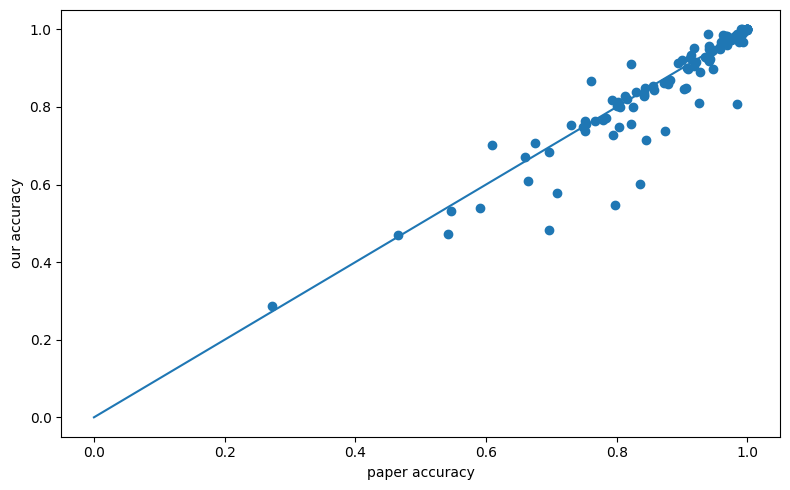

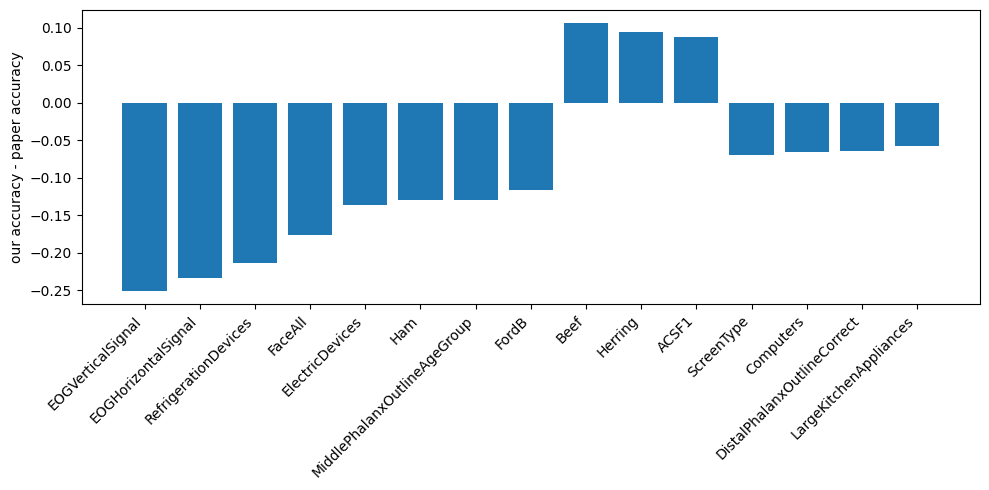

In [19]:
# REPRODUCTION PLOTS
if len(repro_results):
    compare_plot_df = paper_vs_ours.dropna(subset=["our_accuracy"]).copy()

    plt.figure(figsize=(8, 5))
    plt.scatter(compare_plot_df["accuracy"], compare_plot_df["our_accuracy"])
    plt.plot([0, 1], [0, 1])
    plt.xlabel("paper accuracy")
    plt.ylabel("our accuracy")
    plt.tight_layout()
    plt.savefig(REPRO_DIR / "paper_vs_ours_accuracy.png", dpi=300, bbox_inches="tight")
    plt.show()

    top_gap_df = compare_plot_df.reindex(
        compare_plot_df["accuracy_diff"].abs().sort_values(ascending=False).index
    ).head(15)

    plt.figure(figsize=(10, 5))
    plt.bar(top_gap_df["dataset"], top_gap_df["accuracy_diff"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("our accuracy - paper accuracy")
    plt.tight_layout()
    plt.savefig(REPRO_DIR / "largest_accuracy_gaps.png", dpi=300, bbox_inches="tight")
    plt.show()


In [20]:
# IMPROVEMENT MODELS
IMPROVEMENT_MODELS = {
    "MiniRocket_Ridge_10k": {
        "classifier": make_ridge_classifier,
        "num_features": 10_000
    },
    "MiniRocket_Ridge_20k": {
        "classifier": make_ridge_classifier,
        "num_features": 20_000
    },
    "MiniRocket_LogReg_10k": {
        "classifier": make_logreg_classifier,
        "num_features": 10_000
    },
    "MiniRocket_LinearSVC_10k": {
        "classifier": make_linearsvc_classifier,
        "num_features": 10_000
    }
}


In [21]:
# IMPROVEMENT STUDY
def run_improvement_study(datasets, reset=False):
    results_path = IMPROVE_DIR / "improvement_results.csv"
    failed_path = IMPROVE_DIR / "improvement_failed.csv"

    if reset or not results_path.exists():
        results_df = pd.DataFrame()
    else:
        results_df = pd.read_csv(results_path)

    if reset or not failed_path.exists():
        failed_df = pd.DataFrame(columns=["dataset", "model", "error"])
    else:
        failed_df = pd.read_csv(failed_path)

    done_pairs = set(zip(results_df["dataset"], results_df["model"])) if len(results_df) else set()

    for dataset_name in datasets:
        for model_name, config in IMPROVEMENT_MODELS.items():
            if (dataset_name, model_name) in done_pairs:
                continue

            try:
                X_train, y_train, X_test, y_test, le = load_ucr_univariate(dataset_name)

                result = run_minirocket_pipeline(
                    X_train=X_train,
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    classifier=config["classifier"](),
                    num_features=config["num_features"]
                )

                row = {
                    "dataset": dataset_name,
                    "model": model_name,
                    "accuracy": result["accuracy"],
                    "balanced_accuracy": result["balanced_accuracy"],
                    "macro_f1": result["macro_f1"],
                    "train_time_seconds": result["train_time_seconds"],
                    "test_time_seconds": result["test_time_seconds"]
                }

                results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)
                results_df.to_csv(results_path, index=False)

                print(dataset_name, model_name, f"{row['accuracy']:.4f}")

            except Exception as e:
                failed_df = pd.concat([
                    failed_df,
                    pd.DataFrame([{"dataset": dataset_name, "model": model_name, "error": str(e)}])
                ], ignore_index=True)
                failed_df.to_csv(failed_path, index=False)
                print(dataset_name, model_name, "failed")

    return results_df, failed_df


In [25]:

improve_results, improve_failed = run_improvement_study(IMPROVEMENT_DATASETS, reset=False)


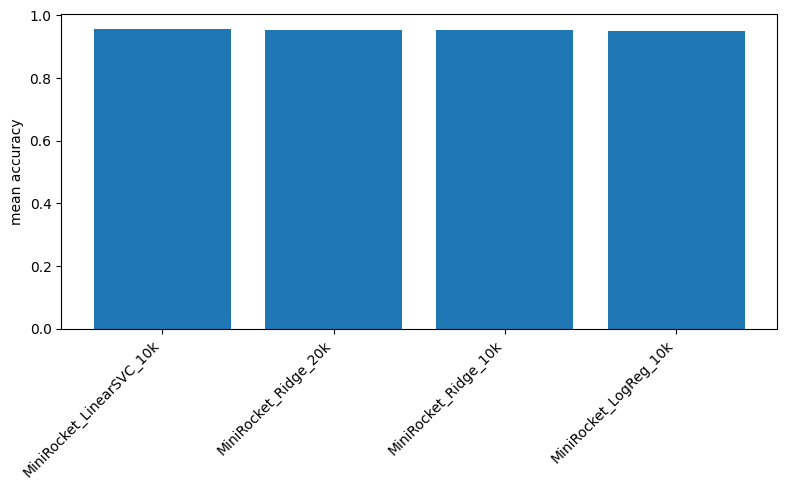

In [27]:

# IMPROVEMENT SUMMARY
if len(improve_results):
    improve_avg = (
        improve_results
        .groupby("model", as_index=False)
        .agg(
            mean_accuracy=("accuracy", "mean"),
            mean_balanced_accuracy=("balanced_accuracy", "mean"),
            mean_macro_f1=("macro_f1", "mean"),
            mean_train_time=("train_time_seconds", "mean"),
            mean_test_time=("test_time_seconds", "mean")
        )
        .sort_values("mean_accuracy", ascending=False)
    )

    ranks = improve_results.copy()
    ranks["rank"] = ranks.groupby("dataset")["accuracy"].rank(ascending=False, method="min")

    improve_rank = (
        ranks
        .groupby("model", as_index=False)
        .agg(
            average_rank=("rank", "mean"),
            mean_accuracy=("accuracy", "mean"),
            mean_macro_f1=("macro_f1", "mean")
        )
        .sort_values("average_rank")
    )

    improve_avg.to_csv(IMPROVE_DIR / "improvement_average_results.csv", index=False)
    improve_rank.to_csv(IMPROVE_DIR / "improvement_average_ranks.csv", index=False)

    plt.figure(figsize=(8, 5))
    plt.bar(improve_avg["model"], improve_avg["mean_accuracy"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("mean accuracy")
    plt.tight_layout()
    plt.savefig(IMPROVE_DIR / "improvement_mean_accuracy.png", dpi=300, bbox_inches="tight")
    plt.show()

    improve_avg


In [29]:
# FINAL FINDINGS FILE
lines = []
lines.append("reproduction")
lines.append("")

if len(repro_summary):
    row = repro_summary.iloc[0]
    lines.append(f"datasets completed: {int(row['datasets_completed'])}/{int(row['datasets_target'])}")
    lines.append(f"mean paper accuracy: {row['mean_paper_accuracy']:.4f}")
    lines.append(f"mean our accuracy: {row['mean_our_accuracy']:.4f}")
    lines.append(f"mean accuracy difference: {row['mean_accuracy_diff']:.4f}")

lines.append("")
lines.append("improvements")
lines.append("")

if len(improve_results):
    best_model = improve_avg.iloc[0]
    lines.append(f"best improvement model: {best_model['model']}")
    lines.append(f"mean accuracy: {best_model['mean_accuracy']:.4f}")
    lines.append(f"mean macro f1: {best_model['mean_macro_f1']:.4f}")

save_text(BASE_DIR / "findings.txt", "\n".join(lines))
print("\n".join(lines))


reproduction

datasets completed: 109/109
mean paper accuracy: 0.8724
mean our accuracy: 0.8578
mean accuracy difference: -0.0146

improvements

best improvement model: MiniRocket_LinearSVC_10k
mean accuracy: 0.9555
mean macro f1: 0.9543


In [6]:
print((df["accuracy_diff"].abs() < 0.01).sum())

52
